# Train


In [ ]:
# Parameters (papermill-friendly)
seed = 42
data_dir = 'data'
processed_dir = 'data/processed'


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

import xgboost as xgb

In [31]:
df = pd.read_csv("../data/processed/FICO_cleaned2.csv", engine="pyarrow")

print("Data shape:", df.shape)
print(df.head())

Data shape: (10459, 24)
   RiskPerformance  ExternalRiskEstimate  MSinceOldestTradeOpen  \
0                0                  55.0                  144.0   
1                0                  61.0                   58.0   
2                0                  67.0                   66.0   
3                0                  66.0                  169.0   
4                0                  81.0                  333.0   

   MSinceMostRecentTradeOpen  AverageMInFile  NumSatisfactoryTrades  \
0                        4.0            84.0                   20.0   
1                       15.0            41.0                    2.0   
2                        5.0            24.0                    9.0   
3                        1.0            73.0                   28.0   
4                       27.0           132.0                   12.0   

   NumTrades60Ever2DerogPubRec  NumTrades90Ever2DerogPubRec  \
0                          3.0                          0.0   
1                   

In [32]:
X = df.drop(columns=["RiskPerformance"], inplace=False)
y = df["RiskPerformance"]

In [33]:
# # Standard scaler
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)
# X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [49]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# Validation Set
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full,
)

print("Train size:", X_train.shape, "Test size:", X_test.shape, "Validation size:", X_valid.shape)

Train size: (6693, 23) Test size: (2092, 23) Validation size: (1674, 23)


In [ ]:
# model = xgb.XGBClassifier(
#     objective='binary:logistic',
#     eval_metric=accuracy_score,
#     use_label_encoder=False,
#     random_state=42,
# )

model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",         # Fast and usually good for tabular data
    n_estimators=1000,          # Let early stopping find the right number
    learning_rate=0.03,         # Smaller LR + more trees = better generalization
    max_depth=4,                # Shallow trees reduce overfitting
    min_child_weight=5,         # Extra regularization
    subsample=0.8,              # Row subsampling
    colsample_bytree=0.8,       # Feature subsampling
    reg_lambda=5.0,             # L2 regularization
    reg_alpha=0.5,              # L1 regularization
    random_state=42,
    use_label_encoder=False,    # For compatibility with older xgboost versions
    early_stopping_rounds=50,   # Stop if no AUC improvement for 50 rounds
)

In [51]:
print("Training XGBoost model with early stopping...")
model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_valid, y_valid)],
    verbose=50,                 # Print progress every 50 rounds
)

print(f"Best iteration: {model.best_iteration}")

Training XGBoost model with early stopping...
[0]	validation_0-auc:0.77394	validation_1-auc:0.76197
[50]	validation_0-auc:0.81190	validation_1-auc:0.79259
[100]	validation_0-auc:0.82323	validation_1-auc:0.79436


c:\Users\hifia\miniconda3\envs\py3.10\lib\site-packages\xgboost\callback.py:386: UserWarning: [15:36:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


[150]	validation_0-auc:0.83138	validation_1-auc:0.79532
[179]	validation_0-auc:0.83546	validation_1-auc:0.79464
Best iteration: 130



Classification report (Test set):
              precision    recall  f1-score   support

           0       0.72      0.76      0.74      1092
           1       0.73      0.68      0.70      1000

    accuracy                           0.72      2092
   macro avg       0.72      0.72      0.72      2092
weighted avg       0.72      0.72      0.72      2092

Accuracy: 0.7246653919694073
Precision: 0.7260127931769723
Recall: 0.681
F1-score: 0.7027863777089783
ROC AUC: 0.7983896520146521

Confusion matrix:
[[835 257]
 [319 681]]


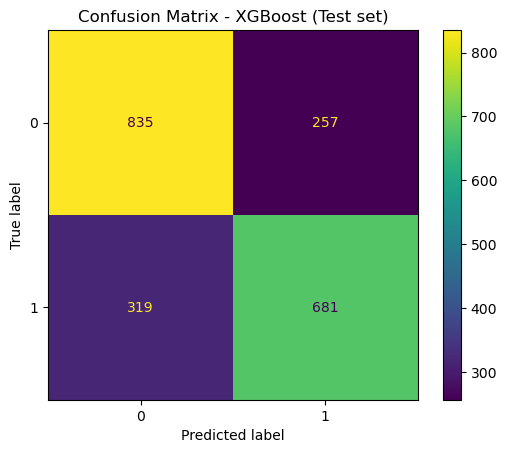

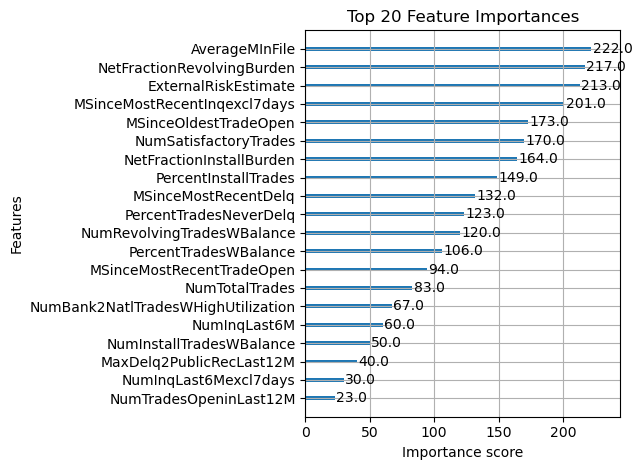

In [52]:
# Evaluate on the held-out test set
y_proba_test = model.predict_proba(X_test)[:, 1]
y_pred_test = (y_proba_test >= 0.5).astype(int)  # Threshold can be tuned if needed

print("\nClassification report (Test set):")
print(classification_report(y_test, y_pred_test))

print("Accuracy:", accuracy_score(y_test, y_pred_test))
print("Precision:", precision_score(y_test, y_pred_test))
print("Recall:", recall_score(y_test, y_pred_test))
print("F1-score:", f1_score(y_test, y_pred_test))
print("ROC AUC:", roc_auc_score(y_test, y_proba_test))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
print("\nConfusion matrix:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - XGBoost (Test set)")
plt.show()

# %%
# Feature importance
xgb.plot_importance(model, max_num_features=20)
plt.title("Top 20 Feature Importances")
plt.tight_layout()
plt.show()

## Since the results aren't great, I'll try using a param search.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

import xgboost as xgb

In [2]:
df = pd.read_csv("../data/processed/FICO_cleaned2.csv", engine="pyarrow")

print("Data shape:", df.shape)
print(df.head())

Data shape: (10459, 24)
   RiskPerformance  ExternalRiskEstimate  MSinceOldestTradeOpen  \
0                0                  55.0                  144.0   
1                0                  61.0                   58.0   
2                0                  67.0                   66.0   
3                0                  66.0                  169.0   
4                0                  81.0                  333.0   

   MSinceMostRecentTradeOpen  AverageMInFile  NumSatisfactoryTrades  \
0                        4.0            84.0                   20.0   
1                       15.0            41.0                    2.0   
2                        5.0            24.0                    9.0   
3                        1.0            73.0                   28.0   
4                       27.0           132.0                   12.0   

   NumTrades60Ever2DerogPubRec  NumTrades90Ever2DerogPubRec  \
0                          3.0                          0.0   
1                   

In [3]:
X = df.drop(columns=["RiskPerformance"], inplace=False)
y = df["RiskPerformance"]
y = 1 - y  # Invert labels: 1 becomes 0, 0 becomes 1

#### Monotonic Constraint Computation

In [4]:
from scipy.stats import spearmanr

monotone_dir = {}   # feature -> {-1, 0, +1}
spearman_corrs = {} # feature -> correlation

for col in X.columns:
    # mask out rows with NaNs in this feature or in y (just in case)
    valid_mask = (~X[col].isna()) & (~y.isna())
    x_valid = X.loc[valid_mask, col]
    y_valid = y.loc[valid_mask]

    # Too few points or constant series -> no reliable correlation
    if len(x_valid) < 10 or x_valid.nunique() < 2 or y_valid.nunique() < 2:
        spearman_corrs[col] = np.nan
        monotone_dir[col] = 0
        continue

    corr, _ = spearmanr(x_valid, y_valid)
    spearman_corrs[col] = corr

    # Small correlations → treat as "no strong direction"
    if np.isnan(corr) or 0 <= abs(corr) < 0.1:  # Previously was 0.02
        monotone_dir[col] = 0
    else:
        monotone_dir[col] = 1 if corr > 0 else -1

print("Spearman correlations:")
for col in X.columns:
    print(f"{col:35s}: {spearman_corrs[col]:.3f}")

print("\nMonotonicity directions:")
for col in X.columns:
    print(f"{col:35s}: {monotone_dir[col]}")


Spearman correlations:
ExternalRiskEstimate               : -0.466
MSinceOldestTradeOpen              : -0.224
MSinceMostRecentTradeOpen          : -0.052
AverageMInFile                     : -0.261
NumSatisfactoryTrades              : -0.151
NumTrades60Ever2DerogPubRec        : 0.208
NumTrades90Ever2DerogPubRec        : 0.176
PercentTradesNeverDelq             : -0.283
MSinceMostRecentDelq               : -0.198
MaxDelq2PublicRecLast12M           : -0.271
MaxDelqEver                        : -0.233
NumTotalTrades                     : -0.110
NumTradesOpeninLast12M             : 0.069
PercentInstallTrades               : 0.129
MSinceMostRecentInqexcl7days       : -0.240
NumInqLast6M                       : 0.147
NumInqLast6Mexcl7days              : 0.142
NetFractionRevolvingBurden         : 0.352
NetFractionInstallBurden           : 0.071
NumRevolvingTradesWBalance         : 0.125
NumInstallTradesWBalance           : 0.058
NumBank2NatlTradesWHighUtilization : 0.283
PercentTradesWBalanc

In [5]:
print("Monotonic directions (Spearman vs Bad=1):")
for col in X.columns:
    print(f"{col:35s}: {monotone_dir[col]}")

# Build monotone_constraints string in the exact feature order
constraints_list = [monotone_dir[col] for col in X.columns]
monotone_constraints_str = "(" + ",".join(str(v) for v in constraints_list) + ")"

print("\nmonotone_constraints:", monotone_constraints_str)
print("Number of features:", len(constraints_list))


Monotonic directions (Spearman vs Bad=1):
ExternalRiskEstimate               : -1
MSinceOldestTradeOpen              : -1
MSinceMostRecentTradeOpen          : 0
AverageMInFile                     : -1
NumSatisfactoryTrades              : -1
NumTrades60Ever2DerogPubRec        : 1
NumTrades90Ever2DerogPubRec        : 1
PercentTradesNeverDelq             : -1
MSinceMostRecentDelq               : -1
MaxDelq2PublicRecLast12M           : -1
MaxDelqEver                        : -1
NumTotalTrades                     : -1
NumTradesOpeninLast12M             : 0
PercentInstallTrades               : 1
MSinceMostRecentInqexcl7days       : -1
NumInqLast6M                       : 1
NumInqLast6Mexcl7days              : 1
NetFractionRevolvingBurden         : 1
NetFractionInstallBurden           : 0
NumRevolvingTradesWBalance         : 1
NumInstallTradesWBalance           : 0
NumBank2NatlTradesWHighUtilization : 1
PercentTradesWBalance              : 1

monotone_constraints: (-1,-1,0,-1,-1,1,1,-1,-1,-1,

#### Class weights

In [6]:
n_bad = y.sum()
n_good = len(y) - n_bad
scale_pos_weight = n_good / n_bad  # Negative class / positive class

print(scale_pos_weight)

0.9159186664224217


#### Splits

In [8]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# Validation Set
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full,
)

print("Train size:", X_train.shape, "Test size:", X_test.shape, "Validation size:", X_valid.shape)

Train size: (6693, 23) Test size: (2092, 23) Validation size: (1674, 23)


#### Hyperparam search

In [22]:
param_dist = {
    "max_depth": [3, 4, 5],
    "min_child_weight": [2, 4, 6, 10],
    "learning_rate": [0.0075, 0.01, 0.015, 0.02],
    "n_estimators": [600, 900, 1200, 1500],
    "subsample": [0.6, 0.75, 0.9],
    "colsample_bytree": [0.6, 0.75, 0.9],
    "reg_alpha": [0, 1],
    "reg_lambda": [0, 1],
    "gamma": [0, 0.1, 0.3, 0.5],
}

# Base model (no early stopping inside CV!)
xgb_base = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    use_label_encoder=False,
    random_state=42,
)

In [23]:
# 5-fold CV, scoring by AUC
search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=120,
    scoring="roc_auc",
    cv=5,  # 5 fold cross validation
    verbose=2,
    n_jobs=16,
    random_state=42,
)

print("Starting hyperparameter search...")
search.fit(X_train_full, y_train_full)

print("\nBest AUC:", search.best_score_)
print("Best params:\n", search.best_params_)

Starting hyperparameter search...
Fitting 5 folds for each of 120 candidates, totalling 600 fits


c:\Users\hifia\miniconda3\envs\py3.10\lib\site-packages\xgboost\training.py:183: UserWarning: [17:29:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Best AUC: 0.7962370662200099
Best params:
 {'subsample': 0.6, 'reg_lambda': 1, 'reg_alpha': 1, 'n_estimators': 1200, 'min_child_weight': 6, 'max_depth': 3, 'learning_rate': 0.0075, 'gamma': 0.1, 'colsample_bytree': 0.6}


In [25]:
print("Best params (Stage-2):")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")

Best params (Stage-2):
  subsample: 0.6
  reg_lambda: 1
  reg_alpha: 1
  n_estimators: 1200
  min_child_weight: 6
  max_depth: 3
  learning_rate: 0.0075
  gamma: 0.1
  colsample_bytree: 0.6


#### Best param training

In [26]:
# best_params = search.best_params_

final_model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    use_label_encoder=False,
    random_state=42,
    early_stopping_rounds=50,
    monotone_constraints=monotone_constraints_str,
    
    # Best params from search
    subsample=0.75,
    reg_lambda=0,
    reg_alpha=1,
    n_estimators=600,
    min_child_weight=10,
    max_depth=4,
    learning_rate=0.01,
    gamma=0,
    colsample_bytree=0.6,
    scale_pos_weight=scale_pos_weight,
)

final_model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=50,
)

[0]	validation_0-auc:0.79226


[50]	validation_0-auc:0.80979
[100]	validation_0-auc:0.81187
[150]	validation_0-auc:0.81400


c:\Users\hifia\miniconda3\envs\py3.10\lib\site-packages\xgboost\callback.py:386: UserWarning: [17:31:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


[200]	validation_0-auc:0.81504
[250]	validation_0-auc:0.81636
[300]	validation_0-auc:0.81741
[350]	validation_0-auc:0.81771
[400]	validation_0-auc:0.81834
[450]	validation_0-auc:0.81834
[500]	validation_0-auc:0.81860
[550]	validation_0-auc:0.81837
[552]	validation_0-auc:0.81836


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.6
,device,None
,early_stopping_rounds,50
,enable_categorical,False
,eval_metric,'auc'


#### 0.5 Thresh Eval


Classification report (Test set):
              precision    recall  f1-score   support

    Good (0)       0.71      0.69      0.70      1000
     Bad (1)       0.72      0.75      0.73      1092

    accuracy                           0.72      2092
   macro avg       0.72      0.72      0.72      2092
weighted avg       0.72      0.72      0.72      2092

Accuracy: 0.7174952198852772
Precision: 0.7218777679362267
Recall: 0.7463369963369964
F1-score: 0.7339036470058532
ROC AUC: 0.7926465201465202

Confusion matrix:
[[686 314]
 [277 815]]


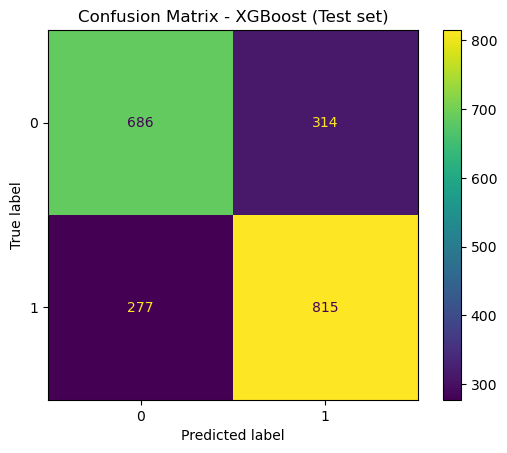

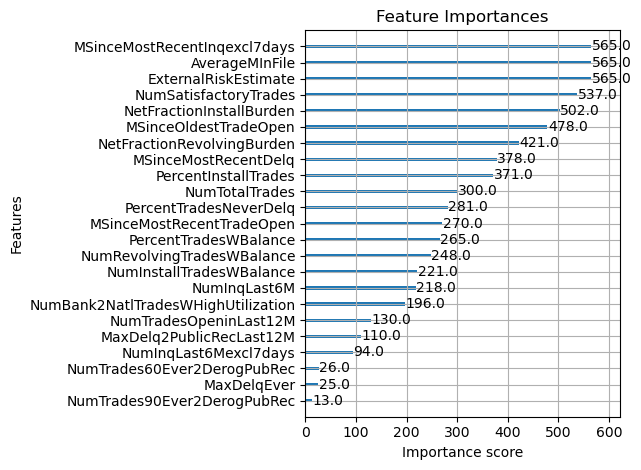

In [27]:
# Evaluate on the held-out test set
y_proba_test = final_model.predict_proba(X_test)[:, 1]
y_pred_test = (y_proba_test >= 0.5).astype(int)

print("\nClassification report (Test set):")
print(classification_report(
    y_test,
    y_pred_test,
    target_names=["Good (0)", "Bad (1)"],
))

print("Accuracy:", accuracy_score(y_test, y_pred_test))
print("Precision:", precision_score(y_test, y_pred_test))
print("Recall:", recall_score(y_test, y_pred_test))
print("F1-score:", f1_score(y_test, y_pred_test))
print("ROC AUC:", roc_auc_score(y_test, y_proba_test))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
print("\nConfusion matrix:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - XGBoost (Test set)")
plt.show()

# %%
# Feature importance
xgb.plot_importance(final_model)
plt.title("Feature Importances")
plt.tight_layout()
plt.show()

### Thresholds are set to 0.5, maybe different thresholds will help performance

In [28]:
y_scores = y_proba_test       # probability that sample is Bad (1)
thresholds = np.linspace(0.0, 1.0, 501)  # 0.0 to 1.0 in 0.002 steps

results = []

for t in thresholds:
    y_t = (y_scores >= t).astype(int)
    
    results.append({
        "threshold": t,
        "recall_bad": recall_score(y_test, y_t, pos_label=1),
        "precision_bad": precision_score(y_test, y_t, pos_label=1, zero_division=0),
        "f1_bad": f1_score(y_test, y_t, pos_label=1),
        "balanced_recall": (recall_score(y_test, y_t, pos_label=1) + recall_score(y_test, y_t, pos_label=0)) / 2,
        "accuracy": accuracy_score(y_test, y_t),
    })

results_df = pd.DataFrame(results)

# Show the best threshold for different objectives
print("Best threshold by F1 (Bad):")
print(results_df.loc[results_df["f1_bad"].idxmax()])

print("\nBest threshold by Recall (Bad):")
print(results_df.loc[results_df["recall_bad"].idxmax()])

print("\nBest threshold by Balanced Accuracy:")
print(results_df.loc[results_df["balanced_recall"].idxmax()])

Best threshold by F1 (Bad):
threshold          0.402000
recall_bad         0.835165
precision_bad      0.694064
f1_bad             0.758105
balanced_recall    0.716582
accuracy           0.721797
Name: 201, dtype: float64

Best threshold by Recall (Bad):
threshold          0.000000
recall_bad         1.000000
precision_bad      0.521989
f1_bad             0.685930
balanced_recall    0.500000
accuracy           0.521989
Name: 0, dtype: float64

Best threshold by Balanced Accuracy:
threshold          0.526000
recall_bad         0.732601
precision_bad      0.734619
f1_bad             0.733608
balanced_recall    0.721800
accuracy           0.722275
Name: 263, dtype: float64


In [ ]:
best_t = 0.402   # example, replace with your chosen one
y_pred_custom = (y_proba_test >= best_t).astype(int)

print(classification_report(y_test, y_pred_custom, target_names=["Good (0)", "Bad (1)"]))
print(confusion_matrix(y_test, y_pred_custom))

              precision    recall  f1-score   support

    Good (0)       0.77      0.60      0.67      1000
     Bad (1)       0.69      0.84      0.76      1092

    accuracy                           0.72      2092
   macro avg       0.73      0.72      0.72      2092
weighted avg       0.73      0.72      0.72      2092

[[598 402]
 [180 912]]
